In [17]:
from astropy import constants, units
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.colors import LinearSegmentedColormap
import matplotlib as mpl
import scipy 
from scipy import signal
from scipy.fft import fft, fftshift
from astropy.units import Quantity
from astropy import units
import matplotlib.ticker as ticker
import cmcrameri.cm as cmc
import sys
from mpl_toolkits.axes_grid1 import ImageGrid
import corner


import hera_sim
from pyuvdata import UVData
from uvtools.dspec import gen_window
from uvtools.plot import waterfall
from uvtools.utils import FFT, fourier_freqs
from hydra_pspec.sys_solver import sys_modes
from astropy import units as u
mpl.rcParams['font.size']=20
from plotting_functions import master_plotter,plot_waterfalls,plot_waterfalls_from_dlfr
from functions import covariance_from_pspec,fourier_operator

In [8]:
def fourier_mode_2d(freqs_Hz, times_sec, modes, box=None):
    """
    Construct a set of 2D Fourier modes from a list of wavenumber integers, 
    to form an incomplete set of 2D Fourier modes.

    Parameters
    ----------
    freqs_Hz (array_like):
        Frequency array, in Hz. Should be ordered.
        
    times_sec (array_like):
        Time array, in hours. Should be ordered.

    modes (list of tuple of int):
        List of mode integer pairs to include in operator.

    box (tuple of tuple):
        NOT IMPLEMENTED
        Keep all modes within a box, defined by the tuple:
        `((delay_min, delay_max), (frate_min, frate_max))`.
        The delays are in ns and the fringe rates in mHz.
    """
    Nfreqs, Ntimes = freqs_Hz.size, times_sec.size
    
    # Get grid spacing in expected units
    dfreq = (freqs_Hz[1] - freqs_Hz[0])
    dtime = (times_sec[1] - times_sec[0])

    # Get FFT wavenumbers
    kfreq = np.fft.fftfreq(Nfreqs, d=dfreq) # sec #* 1e9 # ns
    ktime = np.fft.fftfreq(Ntimes, d=dtime) # Hz * 1e3 # mHz

    # Get FFT mode integers
    nfreq = (np.fft.fftfreq(Nfreqs) * Nfreqs).astype(int)
    ntime = (np.fft.fftfreq(Ntimes) * Ntimes).astype(int)

    # Frequency/time grids with respect to origin
    f = freqs_Hz - freqs_Hz[0]
    t = times_sec - times_sec[0]

    # Get indices of modes we want to keep
    basis_fns = np.zeros((len(modes), Nfreqs, Ntimes), dtype=np.complex128)
    for i, mode in enumerate(modes):
        nf, nt = mode
        print(nf, nt)
        assert isinstance(nf, int), "modes must only contain pairs of integers"
        assert isinstance(nt, int), "modes must only contain pairs of integers"
        assert nf in nfreq, "Delay mode nf=%d not in available range (%d -- %d)." \
            % (nf, nfreq.min(), nfreq.max())
        assert nt in ntime, "Fringe rate mode nt=%d not in available range (%d -- %d)." \
            % (nt, ntime.min(), ntime.max())

        # Get mode indices
        idx_f = np.where(nfreq == nf)[0][0]
        idx_t = np.where(ntime == nt)[0][0]
        #mode_idxs.append( (idx_f, idx_t) )

        print(kfreq[idx_f], ktime[idx_t])

        # Add basis function to operator
        basis_fns[i] = np.exp(2.*np.pi*1.j * (  kfreq[idx_f] * f[:,np.newaxis]
                                     + ktime[idx_t] * t[np.newaxis,:] ) ) \
                     / np.sqrt(Nfreqs * Ntimes)
        
    return basis_fns, kfreq * 1e9, ktime * 1e3


def sys_modes(freqs_Hz, times_sec, modes):
    """
    Construct systematic mode operator, which is a 2D Fourier basis.
    note: mode 0 is DL, mode 1 is FR
    """
    u, kfreq, ktime = fourier_mode_2d(freqs_Hz=freqs_Hz, 
                                      times_sec=times_sec, 
                                      modes=modes)
    return u.reshape((u.shape[0],-1)).T  


In [9]:
Ntimes = 80 #60 #203
Nfreqs = 60
freqs = np.linspace(100., 120., 120) ##120) 
Nfgmodes = 12
freqs = freqs[:Nfreqs]
lsts = np.linspace(0., 1., Ntimes)


In [18]:
sys_modes_operator.shape

(4800, 2)

In [14]:
nm_list = [(0,1),(0,2)]
sys_amps_true = np.array([4. + 1j, 4.1 + 1j, 5. + 1j, 4. + 1j])
sys_modes_operator = sys_modes(freqs_Hz=freqs*1e6, 
                                    times_sec=lsts * 24./(2.*np.pi) * 3600., 
                                    modes=nm_list)

0 1
0.0 7.181302651435001e-05
0 2
0.0 0.00014362605302870003


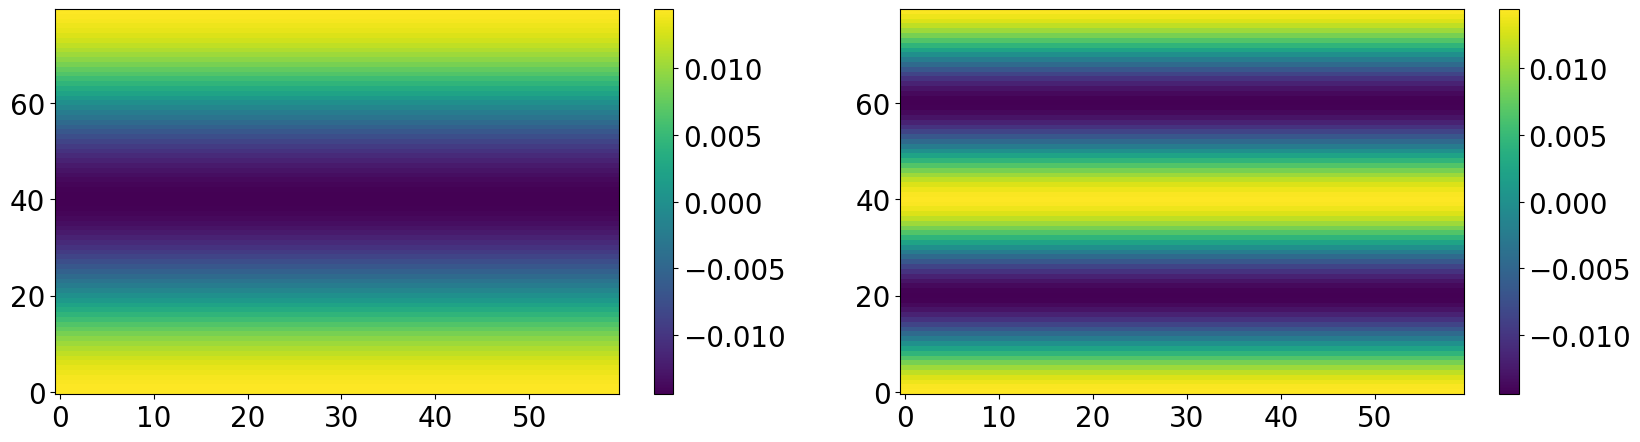

In [15]:
fig, axs = plt.subplots(1,2,figsize=(20,5))

for i in range(2):
    im=axs[i].imshow(sys_modes_operator[:,i].reshape([Nfreqs,Ntimes]).T.real,aspect='auto',origin='lower')
    plt.colorbar(im)

IndexError: index 2 is out of bounds for axis 1 with size 2

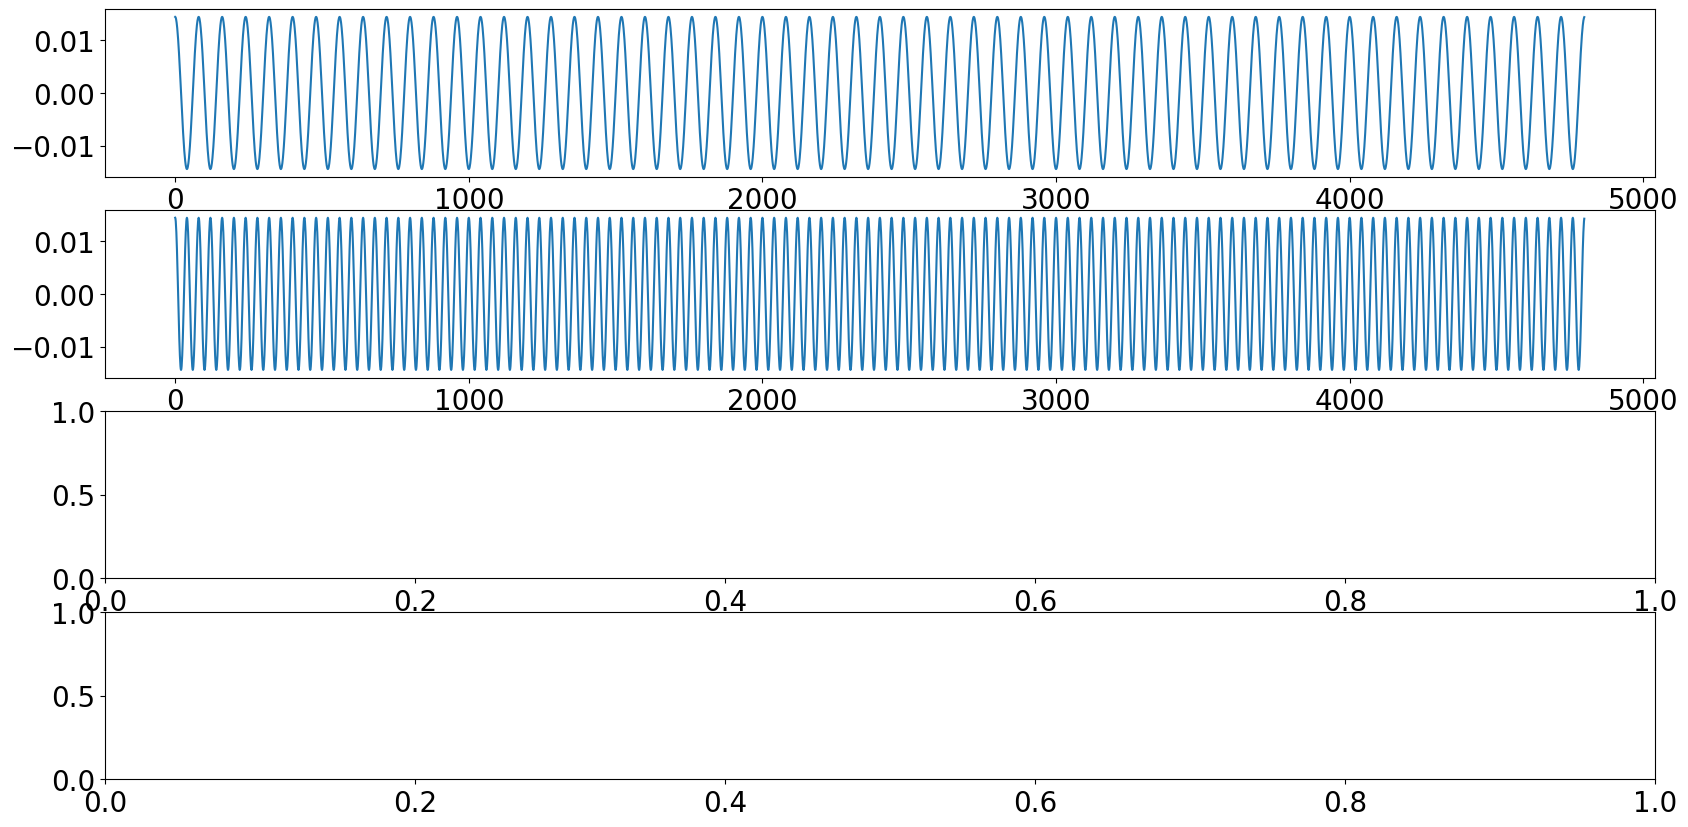

In [16]:
'''Variation of gain with varying bsys'''
fig,axs = plt.subplots(4,1,figsize=(20,10))
for i in range(4):
    axs[i].plot(sys_modes_operator[:,i].real)